# Plant Disease Classification (Healthy vs Disease)

In [37]:
# Imports & Config
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score
import json
from collections import defaultdict
from PIL import Image

DATA_DIR = "../data"
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 3
LR = 1e-3
NUM_WORKERS = 2
SEED = 42
MODEL_DIR = "../models"
RESULTS_DIR = "../results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


# Training augmentations and validation/test transforms

In [40]:
# Enhanced Data Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [42]:
#  Dataset & DataLoader
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)
class_names = full_dataset.classes
print(f"Classes: {class_names}, Total images: {len(full_dataset)}")

class_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_dataset):
    class_indices[label].append(idx)

train_indices, val_indices, test_indices = [], [], []
for label, indices in class_indices.items():
    n = len(indices)
    random.shuffle(indices)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_indices.extend(indices[:n_train])
    val_indices.extend(indices[n_train:n_train + n_val])
    test_indices.extend(indices[n_train + n_val:])

train_subset = Subset(datasets.ImageFolder(root=DATA_DIR, transform=train_transform), train_indices)
val_subset = Subset(datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform), val_indices)
test_subset = Subset(datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform), test_indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_subset)}")

Classes: ['Disease', 'Healthy'], Total images: 892
Train: 623, Val: 133, Test: 136


In [56]:
# Model with Improvements (Simplified - ResNet only) ---
def get_model(num_classes, improvement_level=0):
    # Only use ResNet models to avoid architecture issues
    if improvement_level == 0:
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    elif improvement_level == 1:
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    elif improvement_level == 2: 
        model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
    else:  # Use ResNet152
        model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
    
    # Simple fix for ResNet models only
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    return model

In [58]:
# Enhanced Training Setup
def setup_training(model, improvement_level=0):
    if improvement_level == 0:
        optimizer = optim.Adam(model.parameters(), lr=LR)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    elif improvement_level == 1:
        optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR*10, epochs=EPOCHS, 
                                                steps_per_epoch=len(train_loader))
    
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1 if improvement_level > 0 else 0.0)
    return criterion, optimizer, scheduler

In [60]:
# Training Loop with Improvements
def train_model(improvement_level=0):
    model = get_model(len(class_names), improvement_level).to(DEVICE)
    criterion, optimizer, scheduler = setup_training(model, improvement_level)
    
    best_val_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            if improvement_level >= 2:
                scheduler.step()
            
            train_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        
        train_acc = correct / total
        train_loss = train_loss / total
        
        val_loss, val_acc, _, _, _ = evaluate_model(model, val_loader, criterion)
        
        if improvement_level < 2:
            scheduler.step()
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"{MODEL_DIR}/best_model_imp{improvement_level}.pth")
    
    return model, history

def evaluate_model(model, loader, criterion):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    total = len(all_labels)
    avg_loss = running_loss / total if total else 0.0
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, acc, np.array(all_labels), np.array(all_preds), None

In [62]:
# Simplified Run (Fewer Improvements)
improvement_results = {}
NUM_WORKERS = 0  # Force no multiprocessing

# Only run 3 improvements instead of 4 to test 
for imp_level in range(3):  
    print(f"\n=== Training Improvement Level {imp_level} ===")
    
    try:
        model, history = train_model(imp_level)
        
        model_path = f"{MODEL_DIR}/best_model_imp{imp_level}.pth"
        if os.path.exists(model_path):
            model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
            test_loss, test_acc, y_true, y_pred, _ = evaluate_model(model, test_loader, nn.CrossEntropyLoss())
            
            improvement_results[imp_level] = {
                'test_accuracy': test_acc,
                'test_loss': test_loss,
                'history': history
            }
            
            print(f"Improvement {imp_level} - Test Accuracy: {test_acc:.4f}")
            
    except Exception as e:
        print(f"Error: {e}")
        break


=== Training Improvement Level 0 ===
Epoch 1/3 | Train Loss: 0.2111 Acc: 0.9181 | Val Loss: 0.5265 Acc: 0.8722
Epoch 2/3 | Train Loss: 0.1088 Acc: 0.9711 | Val Loss: 0.0506 Acc: 0.9774
Epoch 3/3 | Train Loss: 0.1245 Acc: 0.9631 | Val Loss: 0.5832 Acc: 0.8722
Improvement 0 - Test Accuracy: 0.9853

=== Training Improvement Level 1 ===
Epoch 1/3 | Train Loss: 0.4790 Acc: 0.8636 | Val Loss: 2.7477 Acc: 0.3383
Epoch 2/3 | Train Loss: 0.2948 Acc: 0.9583 | Val Loss: 0.2464 Acc: 0.9850
Epoch 3/3 | Train Loss: 0.2465 Acc: 0.9823 | Val Loss: 0.2395 Acc: 0.9850
Improvement 1 - Test Accuracy: 0.9779

=== Training Improvement Level 2 ===


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to C:\Users\dell/.cache\torch\hub\checkpoints\resnet101-63fe2227.pth
100%|██████████| 171M/171M [08:45<00:00, 340kB/s]  


Epoch 1/3 | Train Loss: 0.7857 Acc: 0.6533 | Val Loss: 6856861921064.4209 Acc: 0.4887
Epoch 2/3 | Train Loss: 0.8490 Acc: 0.5024 | Val Loss: 21.0434 Acc: 0.4962
Epoch 3/3 | Train Loss: 0.6857 Acc: 0.5618 | Val Loss: 0.7759 Acc: 0.5414
Improvement 2 - Test Accuracy: 0.5809



Best model: Improvement Level 0
Final Test Results:
Accuracy: 0.9853
              precision    recall  f1-score   support

     Disease       0.97      1.00      0.99        66
     Healthy       1.00      0.97      0.99        70

    accuracy                           0.99       136
   macro avg       0.99      0.99      0.99       136
weighted avg       0.99      0.99      0.99       136



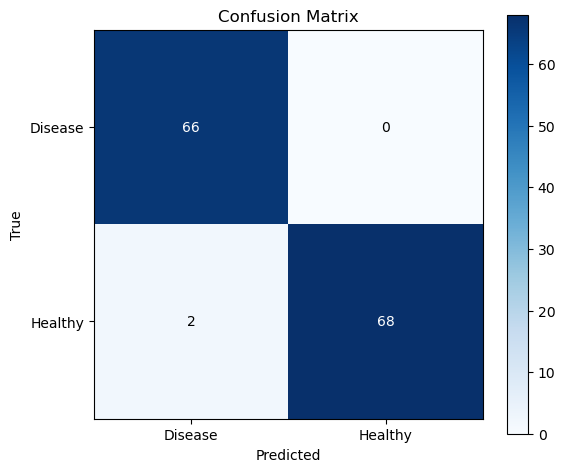

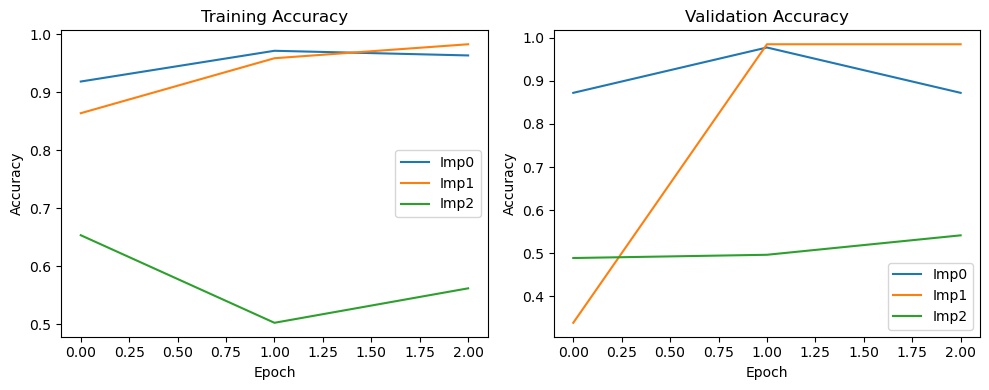

In [66]:
# Final Evaluation & Plots
best_imp_level = max(improvement_results.items(), key=lambda x: x[1]['test_accuracy'])[0]
print(f"\nBest model: Improvement Level {best_imp_level}")

final_model = get_model(len(class_names), best_imp_level).to(DEVICE)
final_model.load_state_dict(torch.load(f"{MODEL_DIR}/best_model_imp{best_imp_level}.pth", map_location=DEVICE, weights_only=True))

test_loss, test_acc, y_true, y_pred, y_probs = evaluate_model(final_model, test_loader, nn.CrossEntropyLoss())

print("Final Test Results:")
print(f"Accuracy: {test_acc:.4f}")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names)
plt.yticks(ticks, class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png")
plt.show()

# Learning Curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
for imp_level, results in improvement_results.items():
    plt.plot(results['history']['train_acc'], label=f'Imp{imp_level}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()

plt.subplot(1,2,2)
for imp_level, results in improvement_results.items():
    plt.plot(results['history']['val_acc'], label=f'Imp{imp_level}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/learning_curves.png")
plt.show()


In [68]:
# Deployment Ready Inference
def predict_image(image_path):
    img = Image.open(image_path).convert('RGB')
    x = val_test_transform(img).unsqueeze(0).to(DEVICE)
    
    final_model.eval()
    with torch.no_grad():
        outputs = final_model(x)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        pred_idx = np.argmax(probs)
        confidence = probs[pred_idx]
    
    return {
        'prediction': class_names[pred_idx],
        'confidence': float(confidence),
        'all_probabilities': {class_names[i]: float(probs[i]) for i in range(len(class_names))}
    }

In [72]:
# Test Unseen Images
extra_images_dir = os.path.join(DATA_DIR)
extra_images = [
    f for f in os.listdir(extra_images_dir) 
    if os.path.isfile(os.path.join(extra_images_dir, f)) 
       and not f.lower().startswith('.')
       and f not in ['Healthy', 'Disease']
]

print(f"Found {len(extra_images)} extra images for manual testing")

results_extra = {}
success_count = 0

for img_file in extra_images:
    img_path = os.path.join(extra_images_dir, img_file)
    
    try:
        # Test if image can be opened
        with Image.open(img_path) as test_img:
            test_img.verify()  # Verify it's a valid image
        
        # If valid, process it
        img = Image.open(img_path).convert('RGB')
        x = val_test_transform(img).unsqueeze(0).to(DEVICE)
        
        final_model.eval()
        with torch.no_grad():
            outputs = final_model(x)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
            pred_idx = np.argmax(probs)
            confidence = probs[pred_idx]
        
        results_extra[img_file] = {
            'prediction': class_names[pred_idx],
            'confidence': float(confidence),
            'all_probabilities': {class_names[i]: float(probs[i]) for i in range(len(class_names))}
        }
        
        print(f"{img_file} → Pred: {class_names[pred_idx]} (Conf: {confidence:.3f})")
        success_count += 1
        
    except Exception as e:
        print(f"{img_file} → ❌ SKIPPED (corrupted/invalid image)")
        continue

print(f"\n✅ Successfully processed {success_count}/{len(extra_images)} images")

Found 8 extra images for manual testing
images (1).jfif → Pred: Healthy (Conf: 0.890)
images (2).jfif → Pred: Healthy (Conf: 0.995)
images (3).jfif → Pred: Disease (Conf: 0.888)
images (4).jfif → Pred: Disease (Conf: 1.000)
images (5).jfif → Pred: Disease (Conf: 0.584)
images (6).jfif → Pred: Healthy (Conf: 0.940)
images (7).jfif → Pred: Healthy (Conf: 0.991)
images.jfif → Pred: Disease (Conf: 0.992)

✅ Successfully processed 8/8 images


In [74]:
# Save Final Artifacts
torch.save(final_model.state_dict(), f"{MODEL_DIR}/final_model.pth")

final_results = {
    'best_improvement_level': int(best_imp_level),
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'class_names': class_names,
    'dataset_size': len(full_dataset),
    'improvement_results': {k: {'test_accuracy': float(v['test_accuracy']), 
                              'test_loss': float(v['test_loss'])} 
                          for k, v in improvement_results.items()}
}

with open(f"{RESULTS_DIR}/final_results.json", 'w') as f:
    json.dump(final_results, f, indent=2)

print("Training completed. Final model and results saved.")

Training completed. Final model and results saved.
